# DMS Load Test Analysis

Analyzes the JSON output of a `loadtest/k6/scenario.js` run (see `loadtest/README.md`).

The k6 script ramps virtual users up over the test duration, runs a mixed
realistic workload (login, folder listing, search, upload, download) through
the gateway, and records:

- `http_req_duration` - built-in per-request response time, tagged with a
  low-cardinality `name` per action (see `withName()` in the k6 script).
- `goodput` - a custom metric, true only when a response is both successful
  (2xx) **and** under the SLA latency threshold (`SLA_MS` below - keep this in
  sync with the `SLA_MS` env var used for the analyzed run).
- `vus` - active virtual user count, i.e. the ramp profile itself.

This notebook loads the most recent `loadtest/results/run-*.json` file and
produces: the ramp profile, throughput over time, response time percentiles
per action over time, goodput vs. error rate over time, and a per-action
summary table.

In [1]:
import glob
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

# Must match the SLA_MS the analyzed run used (default in scenario.js is 1000).
SLA_MS = 1000

RESULTS_DIR = os.path.join("..", "results")
result_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "run-*.json")))
if not result_files:
    raise FileNotFoundError(f"No run-*.json files found in {RESULTS_DIR} - run loadtest/run.sh first")
RESULT_FILE = result_files[-1]  # most recent run; set explicitly to analyze an older one
print(f"Analyzing {RESULT_FILE}")

Analyzing ../results/run-20260815T153206Z.json


In [2]:
# k6's JSON output is JSON Lines: one `Metric` (definition) or `Point`
# (sample) object per line. Only `Point` rows carry data; tags are flattened
# into columns, so different metrics populate different tag columns in the
# same dataframe (e.g. `name` for http_req_duration, `action` for goodput) -
# always filter by `metric` before relying on a metric-specific tag column.
records = []
with open(RESULT_FILE) as f:
    for line in f:
        entry = json.loads(line)
        if entry.get("type") != "Point":
            continue
        data = entry["data"]
        records.append(
            {
                "metric": entry["metric"],
                "time": data["time"],
                "value": data["value"],
                **data.get("tags", {}),
            }
        )

df = pd.DataFrame(records)
df["time"] = pd.to_datetime(df["time"], utc=True)
start_time = df["time"].min()
df["elapsed_s"] = (df["time"] - start_time).dt.total_seconds()
print(f"{len(df)} samples, {df['metric'].nunique()} metrics, "
      f"{df['elapsed_s'].max() / 60:.1f} minutes")
df[["metric", "time", "value", "elapsed_s"]].head()

1186433 samples, 18 metrics, 20.1 minutes


,metric,time,value,elapsed_s
0,http_reqs,2026-08-15 15:32:07.192702268+00:00,1.000000,0.0
1,http_req_duration,2026-08-15 15:32:07.192702268+00:00,242.584611,0.0
2,http_req_blocked,2026-08-15 15:32:07.192702268+00:00,0.278896,0.0
3,http_req_connecting,2026-08-15 15:32:07.192702268+00:00,0.192974,0.0
4,http_req_tls_handshaking,2026-08-15 15:32:07.192702268+00:00,0.000000,0.0


## Ramp profile

The virtual-user count over the test duration - confirms the intended ramp
(ramp-up, hold, ramp-down) actually happened.

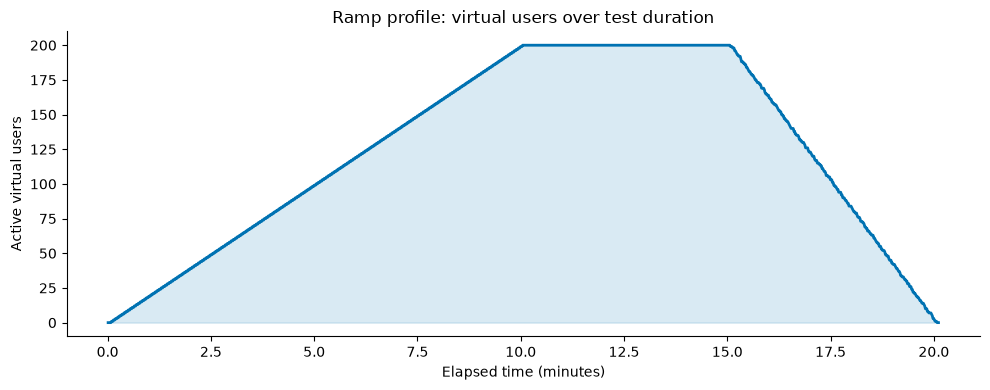

In [3]:
vus = df[df["metric"] == "vus"].sort_values("time")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(vus["elapsed_s"] / 60, vus["value"], color="#0072B2", linewidth=2)
ax.fill_between(vus["elapsed_s"] / 60, vus["value"], color="#0072B2", alpha=0.15)
ax.set_xlabel("Elapsed time (minutes)")
ax.set_ylabel("Active virtual users")
ax.set_title("Ramp profile: virtual users over test duration")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Throughput

Requests per second, resampled into 10s buckets.

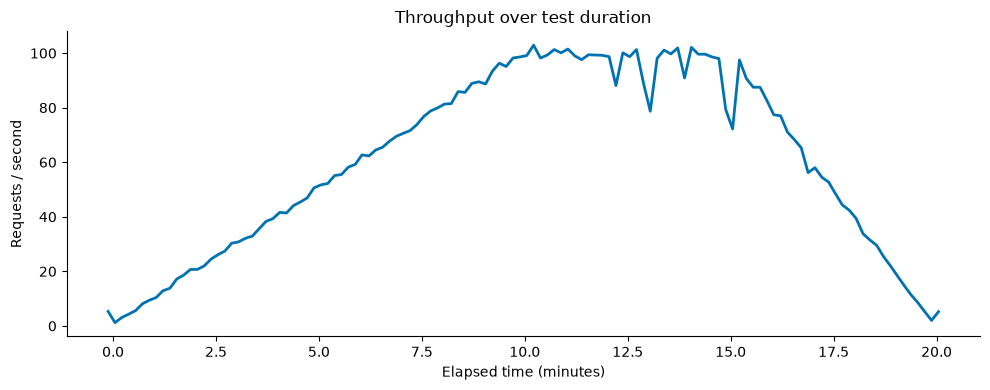

In [4]:
reqs = df[df["metric"] == "http_reqs"].set_index("time").sort_index()
reqs_per_sec = reqs["value"].resample("10s").sum() / 10
elapsed_min = (reqs_per_sec.index - start_time).total_seconds() / 60

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(elapsed_min, reqs_per_sec.values, color="#0072B2", linewidth=2)
ax.set_xlabel("Elapsed time (minutes)")
ax.set_ylabel("Requests / second")
ax.set_title("Throughput over test duration")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Response time by action

p95 response time per action in 30s buckets, restricted to the default-
function workload (`group == ""` excludes `setup()`/`teardown()` samples,
which are one-off and not representative of steady-state load). Colors are
a fixed, colorblind-safe assignment (Okabe-Ito) so the same action always
gets the same color across runs.

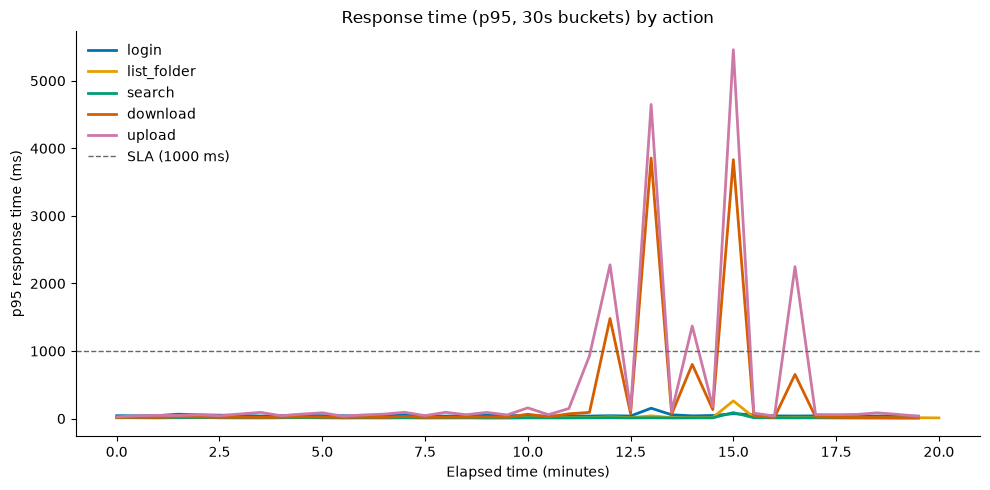

In [5]:
ACTION_COLORS = {
    "login": "#0072B2",
    "list_folder": "#E69F00",
    "search": "#009E73",
    "download": "#D55E00",
    "upload": "#CC79A7",
}

durations = df[
    (df["metric"] == "http_req_duration")
    & (df["group"] == "")
    & (df["name"].isin(ACTION_COLORS))
].copy()
durations["bucket"] = (durations["elapsed_s"] // 30) * 30

p95_by_action = durations.groupby(["bucket", "name"])["value"].quantile(0.95).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for action, color in ACTION_COLORS.items():
    subset = p95_by_action[p95_by_action["name"] == action]
    if subset.empty:
        continue
    ax.plot(subset["bucket"] / 60, subset["value"], label=action, color=color, linewidth=2)

ax.axhline(SLA_MS, color="#666666", linestyle="--", linewidth=1, label=f"SLA ({SLA_MS} ms)")
ax.set_xlabel("Elapsed time (minutes)")
ax.set_ylabel("p95 response time (ms)")
ax.set_title("Response time (p95, 30s buckets) by action")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Goodput vs. error rate

Goodput (green, "good" status semantics) is the share of requests that were
both successful and under the SLA threshold; error rate (red, "critical")
is `http_req_failed` - non-2xx responses or connection-level failures. A
healthy run holds goodput near 100% through the ramp and hold; a widening
gap between goodput and "2xx-but-slow" (goodput dropping while error rate
stays low) indicates the SLA is being missed under load rather than the
backend actually failing requests.

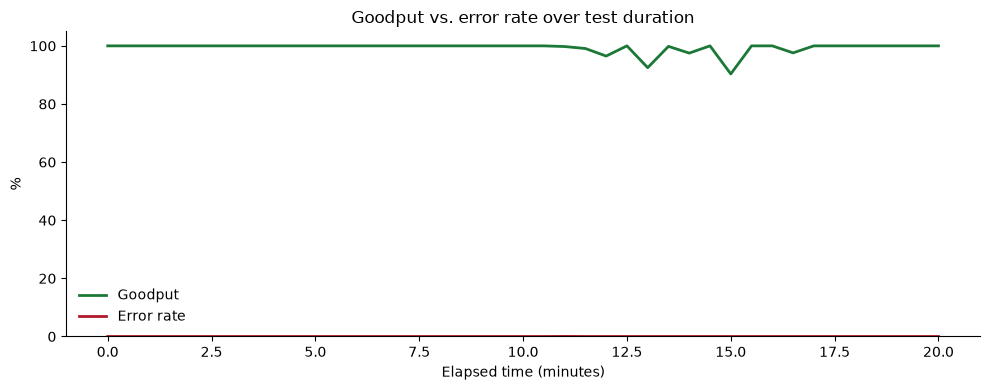

In [6]:
goodput = df[(df["metric"] == "goodput") & (df["group"] == "")].copy()
goodput["bucket"] = (goodput["elapsed_s"] // 30) * 30
goodput_rate = goodput.groupby("bucket")["value"].mean()

failed = df[df["metric"] == "http_req_failed"].copy()
failed["bucket"] = (failed["elapsed_s"] // 30) * 30
failed_rate = failed.groupby("bucket")["value"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(goodput_rate.index / 60, goodput_rate.values * 100, color="#1B7837", linewidth=2, label="Goodput")
ax.plot(failed_rate.index / 60, failed_rate.values * 100, color="#B2182B", linewidth=2, label="Error rate")
ax.set_xlabel("Elapsed time (minutes)")
ax.set_ylabel("%")
ax.set_ylim(0, 105)
ax.set_title("Goodput vs. error rate over test duration")
ax.legend(loc="lower left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Per-action summary

Table view of the same data: request count, response-time percentiles, and
goodput share per action, over the whole run.

In [7]:
summary_rows = []
for action in ACTION_COLORS:
    dur = durations[durations["name"] == action]["value"]
    gp = goodput[goodput["action"] == action]["value"]
    if dur.empty:
        continue
    summary_rows.append(
        {
            "action": action,
            "requests": len(dur),
            "p50_ms": dur.quantile(0.50),
            "p90_ms": dur.quantile(0.90),
            "p95_ms": dur.quantile(0.95),
            "p99_ms": dur.quantile(0.99),
            "goodput_pct": gp.mean() * 100 if not gp.empty else float("nan"),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("action").round(1)
summary

,requests,p50_ms,p90_ms,p95_ms,p99_ms,goodput_pct
action,,,,,,
login,626,31.2,40.0,48.5,63.4,99.8
list_folder,25882,4.6,11.4,14.7,61.3,99.9
search,14771,5.9,9.3,11.2,17.6,99.9
download,18136,10.2,22.3,62.8,2238.1,98.4
upload,14683,27.3,74.9,146.7,3180.9,97.5


## Overall goodput

Single headline number for the whole run - the fraction of default-workload
requests that were both successful and under the SLA threshold.

In [8]:
overall_goodput_pct = goodput["value"].mean() * 100
print(f"Overall goodput: {overall_goodput_pct:.2f}% (SLA = {SLA_MS} ms)")

Overall goodput: 99.05% (SLA = 1000 ms)


## Resource usage by service

Per-container CPU and memory over the same time window, queried live from
Prometheus (scraped from cadvisor - see `infra/prometheus.yml`), correlated
with the ramp profile above. This is what answers "how much CPU/memory does
each service actually need under this load" for service-sizing decisions -
the k6 metrics above measure the *client-observed* experience, this measures
the *cost* of producing it.

Requires Prometheus to still have this run's data (default retention: 15
days) and to have been scraping cadvisor during the run - if cadvisor was
wired up after an older run, this section will show empty results for it.

In [9]:
import requests

PROMETHEUS_URL = os.environ.get("PROMETHEUS_URL", "http://localhost:9090")
RESOURCE_STEP_S = 15  # matches infra/prometheus.yml scrape_interval

run_start = df["time"].min()
run_end = df["time"].max()


def query_range(promql):
    resp = requests.get(
        f"{PROMETHEUS_URL}/api/v1/query_range",
        params={
            "query": promql,
            "start": run_start.timestamp(),
            "end": run_end.timestamp(),
            "step": f"{RESOURCE_STEP_S}s",
        },
        timeout=30,
    )
    resp.raise_for_status()
    payload = resp.json()
    if payload["status"] != "success":
        raise RuntimeError(f"Prometheus query failed: {payload}")

    rows = []
    for series in payload["data"]["result"]:
        service = series["metric"].get("container_label_com_docker_compose_service", "unknown")
        for ts, value in series["values"]:
            rows.append({"service": service, "time": pd.to_datetime(ts, unit="s", utc=True), "value": float(value)})
    return pd.DataFrame(rows)


cpu_df = query_range(
    'sum(rate(container_cpu_usage_seconds_total{container_label_com_docker_compose_service!=""}[1m]))'
    " by (container_label_com_docker_compose_service)"
)
mem_df = query_range(
    'sum(container_memory_usage_bytes{container_label_com_docker_compose_service!=""})'
    " by (container_label_com_docker_compose_service)"
)

if cpu_df.empty and mem_df.empty:
    print(
        "No resource data for this run's time window - Prometheus wasn't scraping "
        "cadvisor yet when this run happened, or the data has since expired."
    )
else:
    for resource_df in (cpu_df, mem_df):
        resource_df["elapsed_min"] = (resource_df["time"] - run_start).dt.total_seconds() / 60
    print(f"{cpu_df['service'].nunique()} services with CPU data, {mem_df['service'].nunique()} with memory data")

48 services with CPU data, 48 with memory data


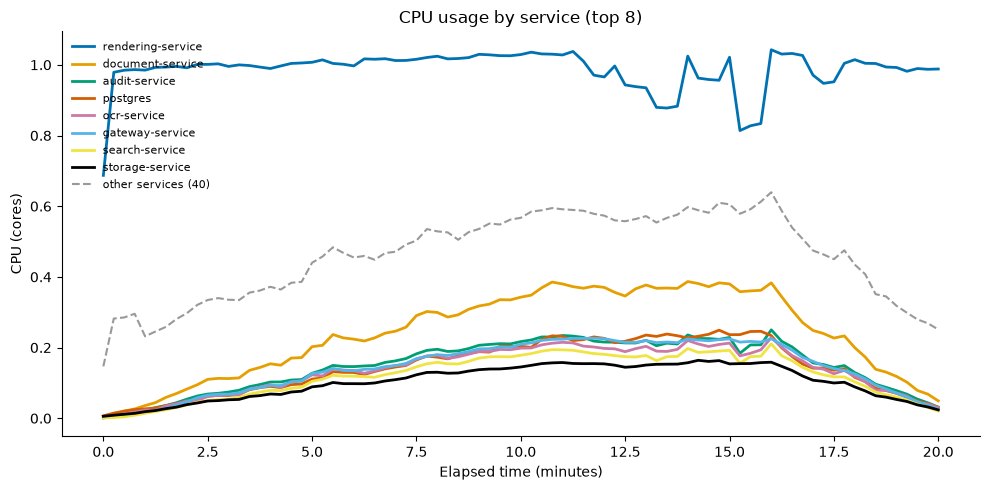

In [10]:
# Fixed, colorblind-safe (Okabe-Ito) palette for up to 8 named series, in a
# stable order - a service keeps its color across runs as long as its rank
# doesn't change. Anything past the top 8 folds into "other services"
# (grey) rather than cycling colors, per the same rule used for actions
# above: color identity should never be auto-generated for a 9th+ series.
TOP_N_SERVICES = 8
SERVICE_PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
OTHER_COLOR = "#999999"


def plot_top_services(resource_df, value_label, title):
    if resource_df.empty:
        print(f"No data for: {title}")
        return

    peak_by_service = resource_df.groupby("service")["value"].max().sort_values(ascending=False)
    top_services = list(peak_by_service.index[:TOP_N_SERVICES])

    fig, ax = plt.subplots(figsize=(10, 5))
    for service, color in zip(top_services, SERVICE_PALETTE):
        subset = resource_df[resource_df["service"] == service].sort_values("time")
        ax.plot(subset["elapsed_min"], subset["value"], label=service, color=color, linewidth=2)

    remaining = resource_df[~resource_df["service"].isin(top_services)]
    if not remaining.empty:
        other_by_time = remaining.groupby("time")["value"].sum().reset_index()
        other_by_time["elapsed_min"] = (other_by_time["time"] - run_start).dt.total_seconds() / 60
        ax.plot(
            other_by_time["elapsed_min"],
            other_by_time["value"],
            label=f"other services ({resource_df['service'].nunique() - len(top_services)})",
            color=OTHER_COLOR,
            linewidth=1.5,
            linestyle="--",
        )

    ax.set_xlabel("Elapsed time (minutes)")
    ax.set_ylabel(value_label)
    ax.set_title(title)
    ax.legend(loc="upper left", frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_top_services(cpu_df, "CPU (cores)", f"CPU usage by service (top {TOP_N_SERVICES})")

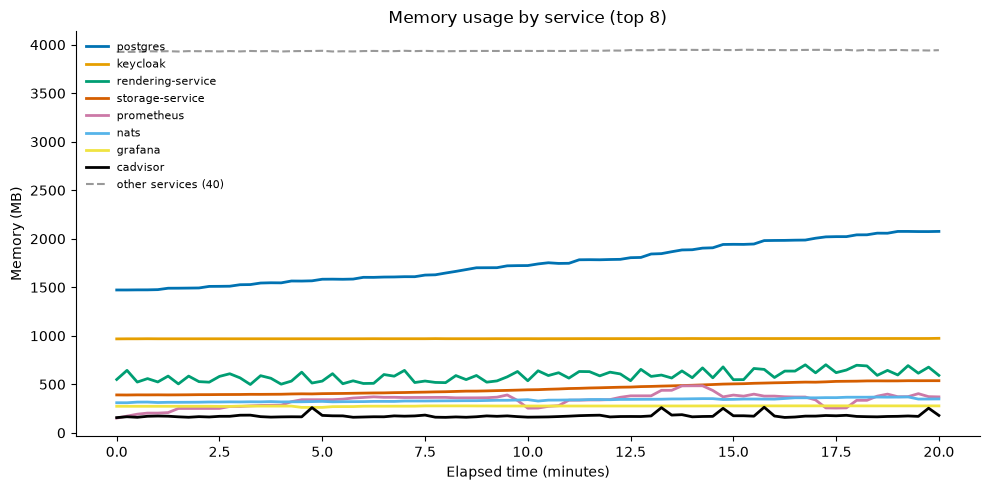

In [11]:
mem_df_mb = mem_df.copy()
if not mem_df_mb.empty:
    mem_df_mb["value"] = mem_df_mb["value"] / (1024**2)
plot_top_services(mem_df_mb, "Memory (MB)", f"Memory usage by service (top {TOP_N_SERVICES})")

## Per-service sizing table

Peak and mean CPU/memory per service across the full run - the two charts
above only show the top 8, this covers every service that reported data.
Peak is what a resource *limit* needs to cover; mean during the hold phase
(steady state at full VU count) is closer to what a resource *request*
should be sized to.

In [12]:
# "Hold phase" = where VUs are at (near) their ramp peak - derived from the
# k6 vus series rather than hardcoded minute offsets, so this still works
# if RAMP_UP/HOLD/RAMP_DOWN were overridden for this run.
max_vus = vus["value"].max()
hold_times = vus.loc[vus["value"] >= max_vus * 0.95, "time"]
hold_start, hold_end = (hold_times.min(), hold_times.max()) if not hold_times.empty else (run_start, run_end)


def summarize(resource_df, unit_label):
    if resource_df.empty:
        return pd.DataFrame()
    peak = resource_df.groupby("service")["value"].max()
    hold_subset = resource_df[(resource_df["time"] >= hold_start) & (resource_df["time"] <= hold_end)]
    mean_at_hold = hold_subset.groupby("service")["value"].mean()
    return pd.DataFrame({f"peak_{unit_label}": peak, f"mean_at_hold_{unit_label}": mean_at_hold})


sizing = summarize(cpu_df, "cores").join(summarize(mem_df_mb, "mb"), how="outer")
sizing = sizing.sort_values("peak_cores", ascending=False).round(3)
sizing

,peak_cores,mean_at_hold_cores,peak_mb,mean_at_hold_mb
service,,,,
rendering-service,1.043,0.972,701.789,600.740
document-service,0.387,0.368,160.734,156.859
audit-service,0.250,0.220,112.777,111.321
postgres,0.249,0.227,2076.129,1823.505
ocr-service,0.228,0.201,169.793,168.192
gateway-service,0.226,0.219,112.738,109.076
search-service,0.210,0.182,122.359,121.481
storage-service,0.164,0.153,537.422,473.248
folder-service,0.157,0.143,118.672,117.135
